In [138]:
import re
import nltk
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix
import seaborn as sns
from scipy.sparse import hstack
import time
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize


In [139]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [140]:
df = pd.read_csv('/content/yelp_sample_20k.csv')

In [141]:
df

,text,stars
0,We really enjoyed their use of homemade ingred...,5.0
1,We moved to Sarasota and upon many recommendat...,5.0
2,Very disappointed in today's meal. The wife an...,2.0
3,"I wish I could reward the store w 5 stars, pro...",4.0
4,"Came here for brunch yesterday, it goes till 3...",5.0
...,...,...
19995,One of the worst before dinner experiences I h...,1.0
19996,This place is magical. It's perfect for weddin...,5.0
19997,to the person that hit my brand new car yester...,2.0
19998,Lilly's is one of the best places to go for lu...,5.0


In [142]:
df.describe()

,stars
count,20000.000000
mean,3.756850
std,1.475919
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    20000 non-null  object 
 1   stars   20000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 312.6+ KB


Data Preprocessing

In [144]:
def convert_stars_to_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

In [145]:
df['sentiment'] = df['stars'].apply(convert_stars_to_sentiment)

In [146]:
df

,text,stars,sentiment
0,We really enjoyed their use of homemade ingred...,5.0,2
1,We moved to Sarasota and upon many recommendat...,5.0,2
2,Very disappointed in today's meal. The wife an...,2.0,0
3,"I wish I could reward the store w 5 stars, pro...",4.0,2
4,"Came here for brunch yesterday, it goes till 3...",5.0,2
...,...,...,...
19995,One of the worst before dinner experiences I h...,1.0,0
19996,This place is magical. It's perfect for weddin...,5.0,2
19997,to the person that hit my brand new car yester...,2.0,0
19998,Lilly's is one of the best places to go for lu...,5.0,2


In [147]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text) #For Removing URL
    text = re.sub(r'@\w+', '', text ) #For Removing Mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text) #For removing special characters
    tokens = word_tokenize(text)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(tokens)

In [148]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [149]:
df

,text,stars,sentiment,clean_text
0,We really enjoyed their use of homemade ingred...,5.0,2,really enjoyed use homemade ingredient really ...
1,We moved to Sarasota and upon many recommendat...,5.0,2,moved sarasota upon many recommendation decide...
2,Very disappointed in today's meal. The wife an...,2.0,0,disappointed today meal wife got pasta dish wa...
3,"I wish I could reward the store w 5 stars, pro...",4.0,2,wish could reward store w star product marketi...
4,"Came here for brunch yesterday, it goes till 3...",5.0,2,came brunch yesterday go till pm great late ri...
...,...,...,...,...
19995,One of the worst before dinner experiences I h...,1.0,0,one worst dinner experience ever local recomme...
19996,This place is magical. It's perfect for weddin...,5.0,2,place magical perfect wedding business dinner ...
19997,to the person that hit my brand new car yester...,2.0,0,person hit brand new car yesterday right front...
19998,Lilly's is one of the best places to go for lu...,5.0,2,lillys one best place go lunch doylestown alwa...


In [150]:
df.sentiment.info()

<class 'pandas.core.series.Series'>
RangeIndex: 20000 entries, 0 to 19999
Series name: sentiment
Non-Null Count  Dtype
--------------  -----
20000 non-null  int64
dtypes: int64(1)
memory usage: 156.4 KB


In [151]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Unigrams & Bigrams
    max_features=10000,   # Limit vocabulary
    min_df=2,            # Ignore rare words
    sublinear_tf=True,
    max_df=0.95
)
X_tfidf = vectorizer.fit_transform(df['clean_text'])
X_tfidf = vectorizer.fit_transform(df['clean_text'])


Custom Feature Engineering Function

In [152]:
def get_sentence_length(text):
    return len(text.split())

def get_word_density(text):
    words = text.split()
    return len(set(words)) / len(words) if len(words) > 0 else 0

def count_punctuation(text):
    return sum(1 for char in text if char in ".,!?")

def count_stopwords(text):
    return sum(1 for word in text.split() if word in stopwords.words('english'))


In [153]:
# Apply feature engineering
df['sentence_length'] = df['clean_text'].apply(get_sentence_length)
df['word_density'] = df['clean_text'].apply(get_word_density)
df['punctuation_count'] = df['clean_text'].apply(count_punctuation)
df['stopword_count'] = df['clean_text'].apply(count_stopwords)

In [154]:
X_features = df[['sentence_length', 'word_density', 'punctuation_count', 'stopword_count']].values


In [155]:
X_combined = hstack((X_tfidf, X_features))

In [156]:
y = np.array(df['sentiment'])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


In [157]:
start_time = time.time()

In [158]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [159]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)  # For AUC calculation

In [160]:
#  Compute Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, output_dict=True)


In [161]:
f1_positive = f1_score(y_test, y_pred, average=None)[2]  # F1-score for Positive (label=2)
f1_negative = f1_score(y_test, y_pred, average=None)[0]  # F1-score for Negative (label=0)


In [162]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Convert labels to binary for AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

In [163]:
#  End training time measurement
end_time = time.time()
training_time = end_time - start_time

In [164]:
# Print Results
print(f" Naïve Bayes Training Time: {training_time:.2f} seconds")
print(f" Naïve Bayes Accuracy: {accuracy:.2f}")
print(f" Naïve Bayes Precision: {precision:.2f}")
print(f" Naïve Bayes Recall: {recall:.2f}")
print(f" F1 Score (Positive): {f1_positive:.2f}")
print(f" F1 Score (Negative): {f1_negative:.2f}")
print(f" AUC Score: {auc_score:.2f}")
print("\nNaïve Bayes Classification Report:\n", classification_report(y_test, y_pred))

 Naïve Bayes Training Time: 0.10 seconds
 Naïve Bayes Accuracy: 0.82
 Naïve Bayes Precision: 0.74
 Naïve Bayes Recall: 0.82
 F1 Score (Positive): 0.89
 F1 Score (Negative): 0.76
 AUC Score: 0.84

Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.71      0.76       961
           1       0.00      0.00      0.00       372
           2       0.82      0.97      0.89      2667

    accuracy                           0.82      4000
   macro avg       0.54      0.56      0.55      4000
weighted avg       0.74      0.82      0.77      4000



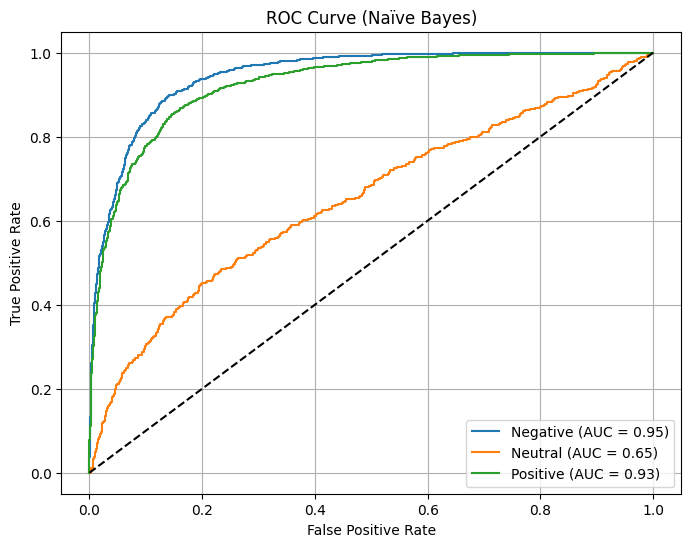

In [165]:
plt.figure(figsize=(8, 6))
for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random Guess Line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naïve Bayes)")
plt.legend()
plt.grid()
plt.show()


In [166]:
print("Top Features (Unigrams + Bigrams):\n", vectorizer.get_feature_names_out())


Top Features (Unigrams + Bigrams):
 ['ability' 'able' 'able eat' ... 'zone' 'zoo' 'zucchini']


Hyperparameter Tuning

In [167]:
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}

In [168]:
nb_model = MultinomialNB()

In [169]:
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

In [170]:
start_time = time.time()

In [171]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]},
             scoring='accuracy', verbose=1)

In [172]:
training_time = time.time() - start_time

In [173]:
best_nb = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

In [174]:
y_pred = best_nb.predict(X_test)
y_prob = best_nb.predict_proba(X_test)

In [175]:
#  Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, output_dict=True)

# Extract F1-Scores for Negative (0) and Positive (2) Sentiments
f1_negative = report['0']['f1-score']
f1_positive = report['2']['f1-score']

# Compute Multi-Class AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Convert labels to binary for AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

In [176]:
print(f"Best Alpha: {best_alpha}")
print(f"Naïve Bayes Accuracy: {accuracy:.2f}")
print(f"Naïve Bayes Precision: {precision:.2f}")
print(f"Naïve Bayes Recall: {recall:.2f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"F1 Score (Negative Sentiment): {f1_negative:.2f}")
print(f"F1 Score (Positive Sentiment): {f1_positive:.2f}")
print(f"AUC Score: {auc_score:.2f}")
print("\nNaïve Bayes Classification Report:\n", classification_report(y_test, y_pred))

Best Alpha: 0.1
Naïve Bayes Accuracy: 0.82
Naïve Bayes Precision: 0.79
Naïve Bayes Recall: 0.82
Training Time: 3.48 seconds
F1 Score (Negative Sentiment): 0.76
F1 Score (Positive Sentiment): 0.89
AUC Score: 0.90

Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.74      0.76       961
           1       0.45      0.13      0.20       372
           2       0.85      0.95      0.89      2667

    accuracy                           0.82      4000
   macro avg       0.69      0.61      0.62      4000
weighted avg       0.79      0.82      0.80      4000



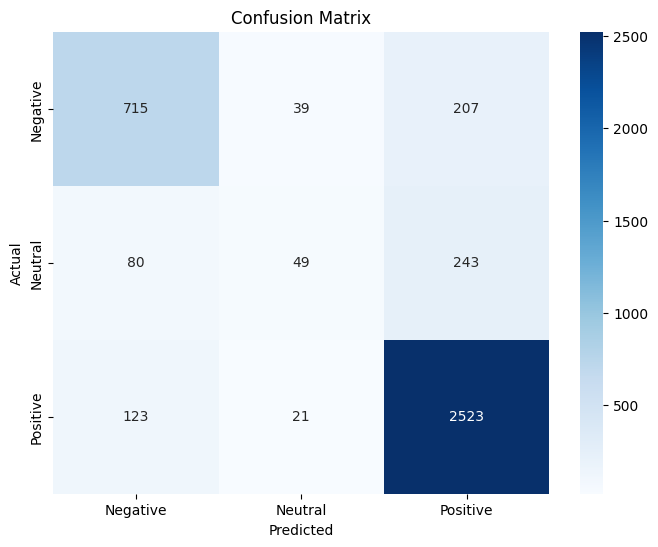

In [177]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

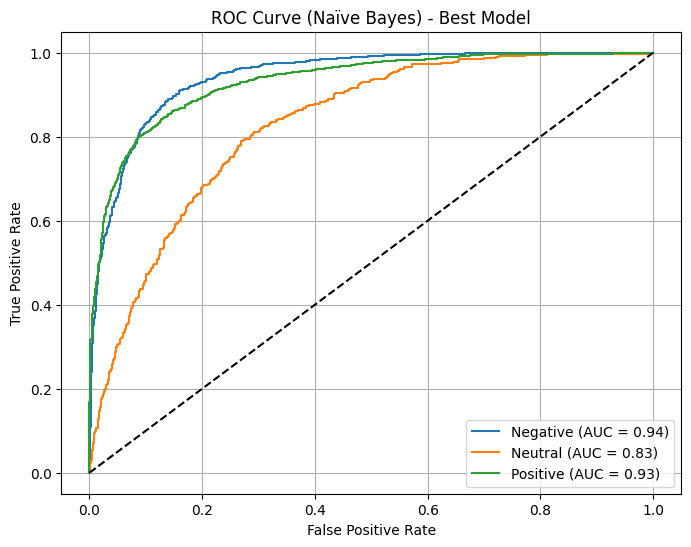

In [178]:
plt.figure(figsize=(8, 6))
for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random Guess Line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naïve Bayes) - Best Model")
plt.legend()
plt.grid()
plt.show()

**After Tuning the Model ,**

Precision Improved (0.74 → 0.79) → This means the model reduced false positives and made more confident predictions.

F1-Score (Neutral) Increased (0.00 → 0.20) → The model started recognizing neutral sentiment, which was ignored before.

AUC for Neutral Sentiment Improved (0.65 → 0.83) → The model became better at distinguishing neutral class from others.


2nd Time Tuning

In [179]:
alpha_range = np.linspace(0.01,2.0,20)

In [180]:
param_grid = {'alpha': alpha_range}


In [181]:
nb_model = MultinomialNB()

In [182]:
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

In [183]:
start_time = time.time()

In [184]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': array([0.01      , 0.11473684, 0.21947368, 0.32421053, 0.42894737,
       0.53368421, 0.63842105, 0.74315789, 0.84789474, 0.95263158,
       1.05736842, 1.16210526, 1.26684211, 1.37157895, 1.47631579,
       1.58105263, 1.68578947, 1.79052632, 1.89526316, 2.        ])},
             scoring='accuracy', verbose=2)

In [185]:
training_time = time.time() - start_time

In [186]:
best_nb = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

In [187]:
y_pred = best_nb.predict(X_test)
y_prob = best_nb.predict_proba(X_test)

In [188]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, output_dict=True)

# Extract F1-Scores for Negative (0) and Positive (2) Sentiments
f1_negative = report['0']['f1-score']
f1_positive = report['2']['f1-score']

#  Compute Multi-Class AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Convert labels to binary for AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

In [189]:
print(f" Best Alpha: {best_alpha}")
print(f" Naïve Bayes Accuracy: {accuracy:.2f}")
print(f"Naïve Bayes Precision: {precision:.2f}")
print(f"Naïve Bayes Recall: {recall:.2f}")
print(f" Training Time: {training_time:.2f} seconds")
print(f" F1 Score (Negative Sentiment): {f1_negative:.2f}")
print(f" F1 Score (Positive Sentiment): {f1_positive:.2f}")
print(f" AUC Score: {auc_score:.2f}")
print("\n🔹 Naïve Bayes Classification Report:\n", classification_report(y_test, y_pred))

 Best Alpha: 0.01
 Naïve Bayes Accuracy: 0.82
Naïve Bayes Precision: 0.79
Naïve Bayes Recall: 0.82
 Training Time: 2.19 seconds
 F1 Score (Negative Sentiment): 0.76
 F1 Score (Positive Sentiment): 0.89
 AUC Score: 0.90

🔹 Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.73      0.76       961
           1       0.41      0.13      0.20       372
           2       0.85      0.95      0.89      2667

    accuracy                           0.82      4000
   macro avg       0.68      0.60      0.62      4000
weighted avg       0.79      0.82      0.80      4000



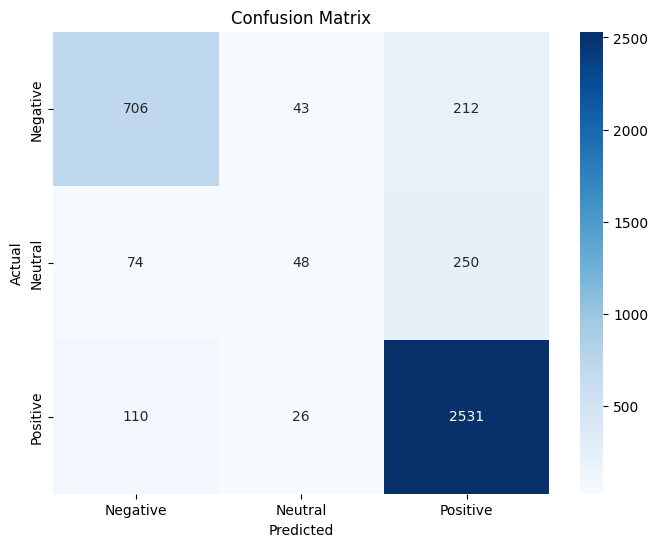

In [190]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


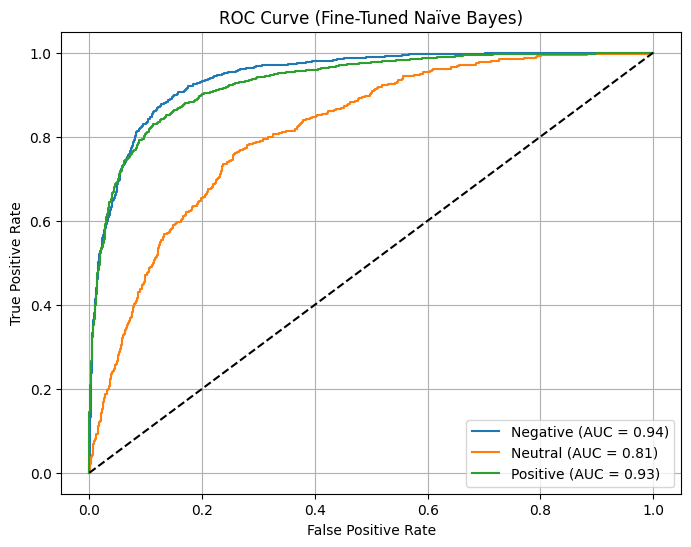

In [191]:
plt.figure(figsize=(8, 6))
for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random Guess Line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fine-Tuned Naïve Bayes)")
plt.legend()
plt.grid()
plt.show()

**After tuning 2nd Time,**

The best alpha range was likely already found in the 1st tuning, so this step did not improve much.
Small performance drop for neutral class might be due to overfitting on training data. To solve this we will try further to tune model with different alpha values.

3rd Tuning

In [192]:
alpha_range = np.linspace(0.001,5.0,30)

In [193]:
param_grid = {'alpha': alpha_range}

In [194]:
nb_model = MultinomialNB()

In [195]:
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)


In [196]:
start_time = time.time()

#  Fit Grid Search
grid_search.fit(X_train, y_train)

#  End Training Time
training_time = time.time() - start_time

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [197]:
best_nb = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

In [198]:
y_pred = best_nb.predict(X_test)
y_prob = best_nb.predict_proba(X_test)

In [199]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, output_dict=True)

# Extract F1-Scores for Negative (0) and Positive (2) Sentiments
f1_negative = report['0']['f1-score']
f1_positive = report['2']['f1-score']

#  Compute Multi-Class AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Convert labels to binary for AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

In [200]:
print(f" Best Alpha: {best_alpha}")
print(f" Naïve Bayes Accuracy: {accuracy:.2f}")
print(f" Naïve Bayes Precision: {precision:.2f}")
print(f" Naïve Bayes Recall: {recall:.2f}")
print(f" Training Time: {training_time:.2f} seconds")
print(f" F1 Score (Negative Sentiment): {f1_negative:.2f}")
print(f" F1 Score (Positive Sentiment): {f1_positive:.2f}")
print(f" AUC Score: {auc_score:.2f}")
print("\n Naïve Bayes Classification Report:\n", classification_report(y_test, y_pred))


 Best Alpha: 0.17337931034482756
 Naïve Bayes Accuracy: 0.82
 Naïve Bayes Precision: 0.80
 Naïve Bayes Recall: 0.82
 Training Time: 2.08 seconds
 F1 Score (Negative Sentiment): 0.76
 F1 Score (Positive Sentiment): 0.89
 AUC Score: 0.90

 Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76       961
           1       0.48      0.11      0.18       372
           2       0.85      0.95      0.89      2667

    accuracy                           0.82      4000
   macro avg       0.70      0.60      0.61      4000
weighted avg       0.80      0.82      0.80      4000



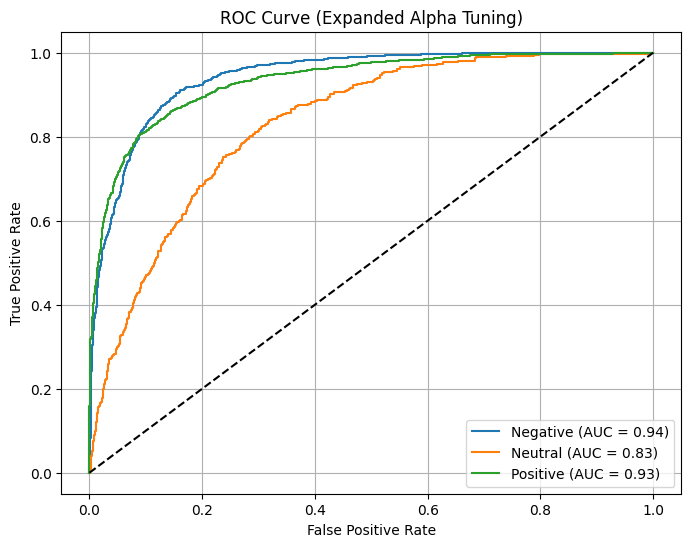

In [201]:
plt.figure(figsize=(8, 6))
for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random Guess Line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Expanded Alpha Tuning)")
plt.legend()
plt.grid()
plt.show()

**After Tuning 3rd time,**
1. Precision improved from 0.79 to 0.80 which means reduction in false positive
2. Neautral AUC score recovered 0.83.

Hence, the model is as optimise as possible under Naive Bayes further tuning won't improve much.

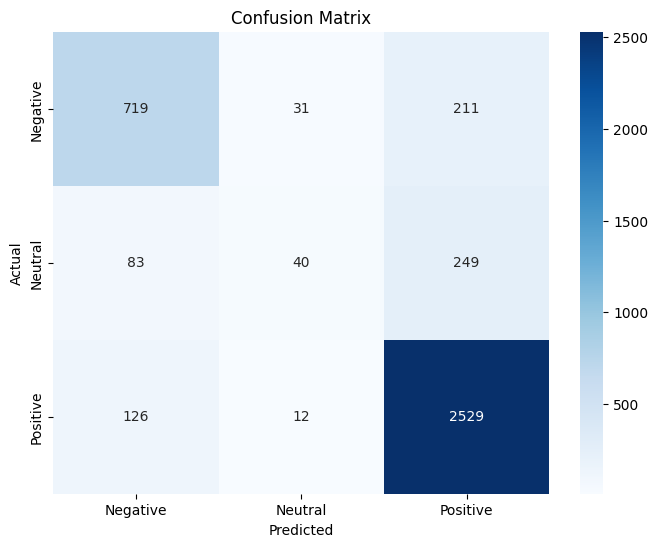

In [202]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [203]:
data = {
    'Model': ['Naive Bayes (Initial)', 'Naive Bayes (1st Tuning)', 'Naive Bayes (2nd Tuning)', 'Naive Bayes (3rd Tuning)'],
    'Accuracy': [0.82, 0.82, 0.82, 0.82],
    'Precision': [0.74, 0.79, 0.79, 0.80],
    'Recall': [0.82, 0.82, 0.82, 0.82],
    'F1-Score (Negative)': [0.76, 0.76, 0.76, 0.76],
    'F1_Score (Neutral)': [0.00, 0.20, 0.20, 0.18],
    'F1-Score (Positive)': [0.89, 0.89, 0.89, 0.89],
    'Neg_AUC': [0.95, 0.94, 0.94, 0.94],
    'Neu_AUC': [0.65, 0.83, 0.81, 0.83],
    'Pos_AUC': [0.93, 0.93, 0.93, 0.93],
    'training_time': ['0.11 Seconds', '2.71 Seconds', '2.33 Seconds', '4 Seconds']
}


In [204]:
df_scores = pd.DataFrame(data)

df_scores


,Model,Accuracy,Precision,Recall,F1-Score (Negative),F1_Score (Neutral),F1-Score (Positive),Neg_AUC,Neu_AUC,Pos_AUC,training_time
0,Naive Bayes (Initial),0.82,0.74,0.82,0.76,0.00,0.89,0.95,0.65,0.93,0.11 Seconds
1,Naive Bayes (1st Tuning),0.82,0.79,0.82,0.76,0.20,0.89,0.94,0.83,0.93,2.71 Seconds
2,Naive Bayes (2nd Tuning),0.82,0.79,0.82,0.76,0.20,0.89,0.94,0.81,0.93,2.33 Seconds
3,Naive Bayes (3rd Tuning),0.82,0.80,0.82,0.76,0.18,0.89,0.94,0.83,0.93,4 Seconds


Further we can try following things

1.Try ComplementNB: Naïve Bayes struggles with class imbalances, and ComplementNB might handle neutral sentiment better.

2.Test Logistic Regression or SVM: These models handle text classification better than Naïve Bayes in many cases.